<a href="https://colab.research.google.com/github/SindhuMH/cartoon_generator/blob/image_generator_codes/stable_diffusion_image_gen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q diffusers transformers accelerate safetensors

In [3]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_ROOT = '/content/drive/MyDrive/panchatantra_assets'
import os
os.makedirs(OUTPUT_ROOT, exist_ok=True)

Mounted at /content/drive


Using existing style reference: /content/drive/MyDrive/panchatantra_assets/style_reference.png


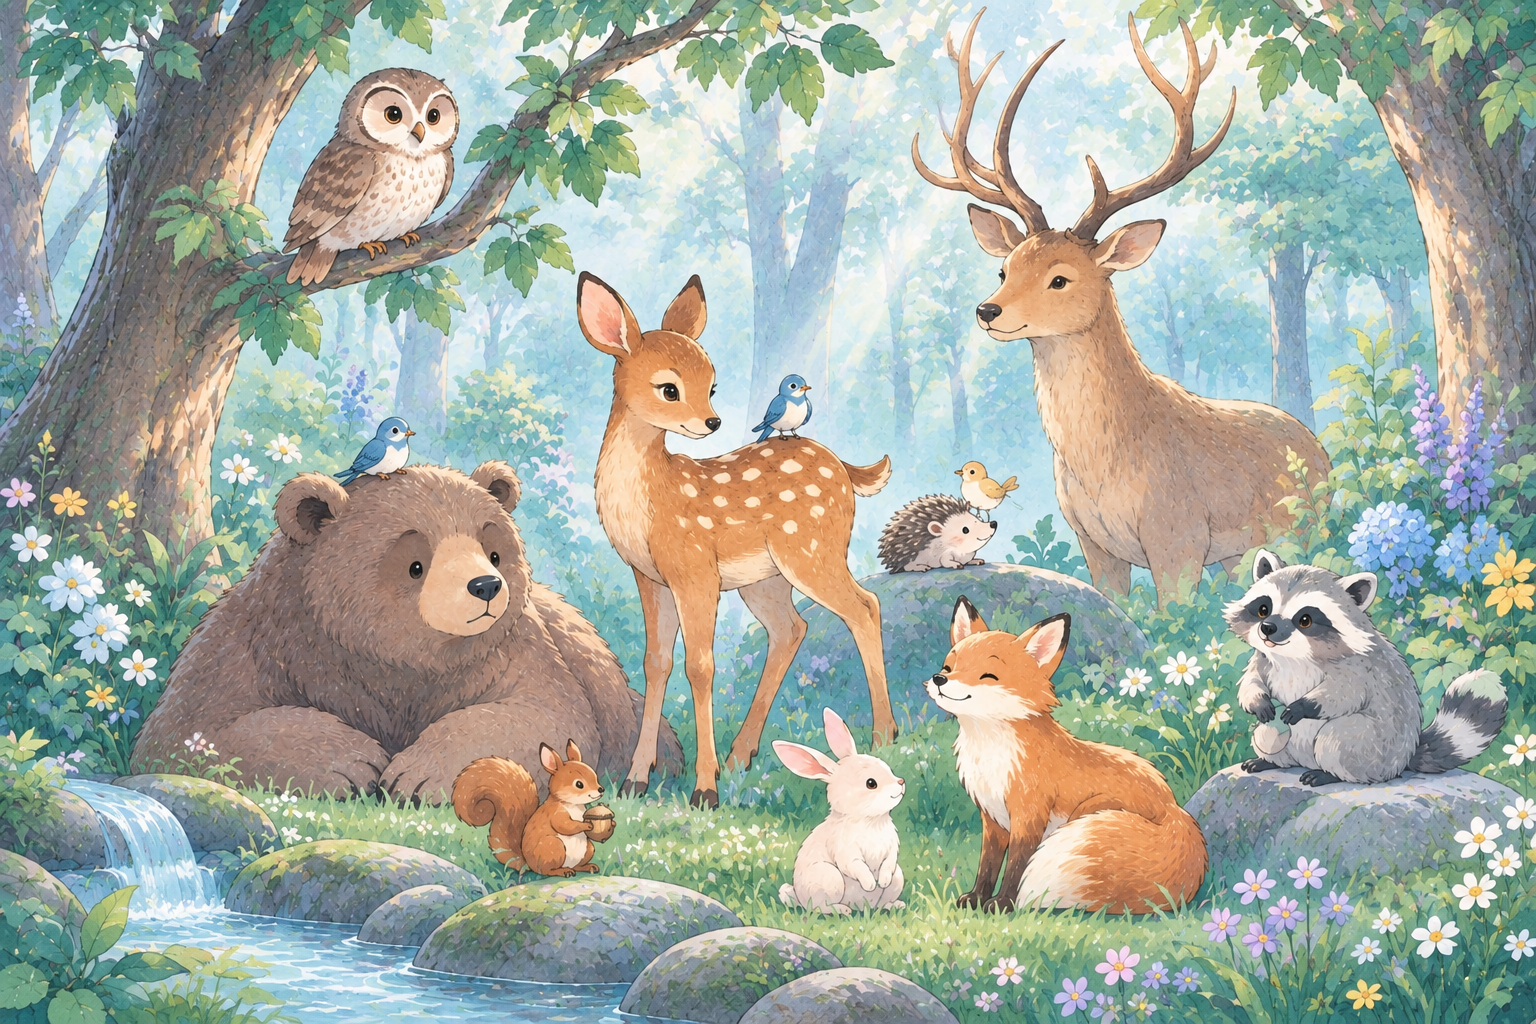

In [4]:
from pathlib import Path
from PIL import Image

STYLE_REF_PATH = Path(OUTPUT_ROOT) / 'style_reference.png'

# if not STYLE_REF_PATH.exists():
#     from google.colab import files
#     print("No saved style reference found — please upload one now.")
#     uploaded = files.upload()
#     uploaded_name = next(iter(uploaded))
#     Image.open(uploaded_name).convert("RGB").save(STYLE_REF_PATH)
#     print(f"Saved to {STYLE_REF_PATH} for future sessions.")
# else:
print(f"Using existing style reference: {STYLE_REF_PATH}")

style_reference = Image.open(STYLE_REF_PATH).convert("RGB")
style_reference

In [5]:
import torch
from PIL import Image

from diffusers import AutoPipelineForText2Image
from transformers import CLIPVisionModelWithProjection

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


In [6]:
MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"

IP_ADAPTER_REPO = "h94/IP-Adapter"
IP_ADAPTER_WEIGHT = "ip-adapter-plus_sdxl_vit-h.safetensors"

# # Your style/reference image
# style_reference = Image.open(
#     "/kaggle/input/YOUR_DATASET/style_reference.png"
# ).convert("RGB")

print("Reference image:", style_reference.size)
# display(style_reference)

image_encoder = CLIPVisionModelWithProjection.from_pretrained(
    IP_ADAPTER_REPO,
    subfolder="models/image_encoder",
    torch_dtype=torch.float16,
)
print("loaded vision encoder")

pipe = AutoPipelineForText2Image.from_pretrained(
    MODEL_ID,
    image_encoder=image_encoder,
    torch_dtype=torch.float16,
    variant="fp16",
)

print("created pipeline")

pipe.load_ip_adapter(
    IP_ADAPTER_REPO,
    subfolder="sdxl_models",
    weight_name=IP_ADAPTER_WEIGHT,
)

pipe.set_ip_adapter_scale(0.45)

print("loaded ip adapter")
pipe.enable_model_cpu_offload()
# pipe.to("cuda")

Reference image: (1536, 1024)


config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

models/image_encoder/model.safetensors: reconstructing file:   0%|          |  0.00B / 2.53GB            

models/image_encoder/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

...

created pipeline


sdxl_models/ip-adapter-plus_sdxl_vit-h.s(…): reconstructing file:   0%|          |  0.00B /  848MB            

sdxl_models/ip-adapter-plus_sdxl_vit-h.s(…): downloading bytes:           |  0.00B            

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


loaded ip adapter


In [7]:
prompt = """
A cute little fox character standing in an enchanted forest,
wearing a small cream-colored dress and a blue scarf.
The fox has large expressive eyes and a friendly, playful expression.

Whimsical children's storybook illustration,
elegant character design,
soft pastel colors,
clean shapes,
beautiful detailed environment,
soft lighting,
high quality digital illustration.
"""

negative_prompt = """
photorealistic,
photograph,
3d render,
cgi,
blurry,
low quality,
deformed,
bad anatomy,
extra limbs,
extra fingers,
duplicate character,
multiple characters,
cropped,
text,
watermark,
logo
"""

  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


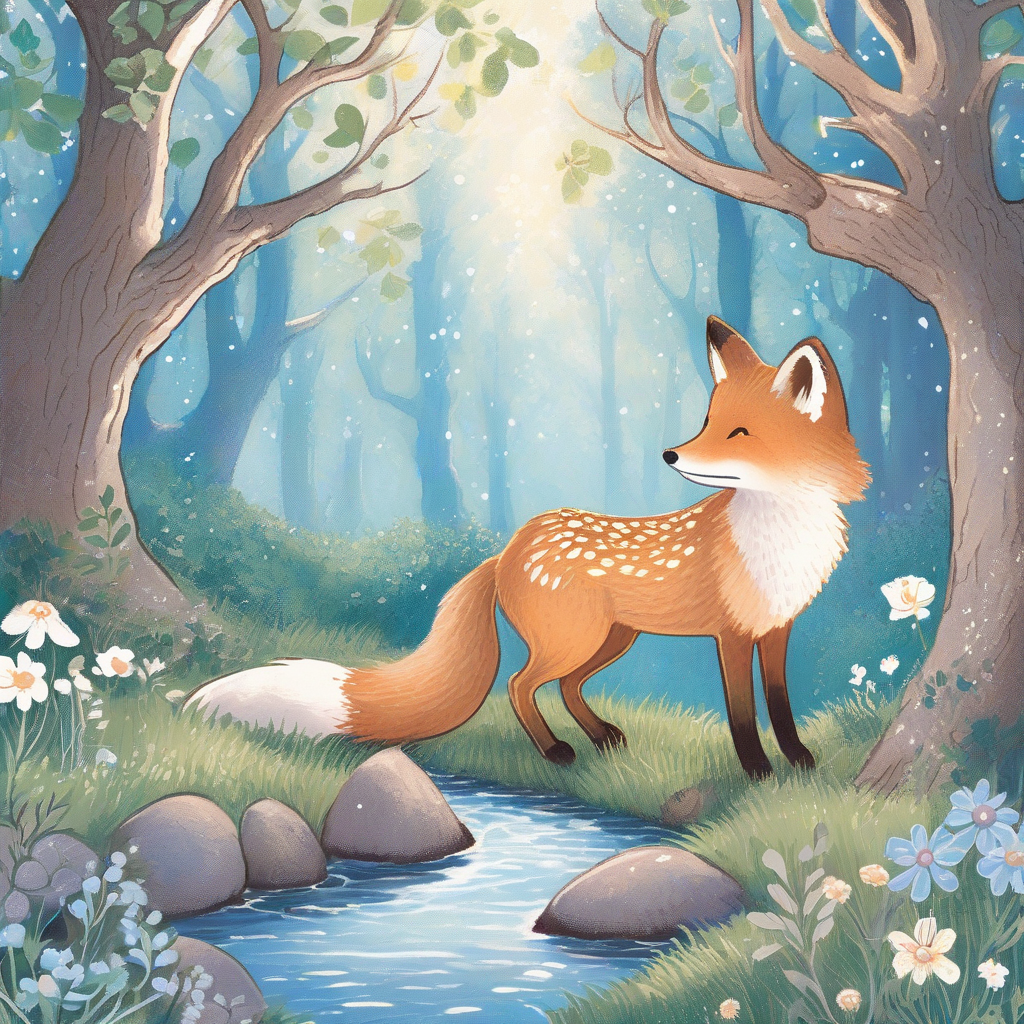

In [8]:
generator = torch.Generator(device="cuda").manual_seed(42)

result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    ip_adapter_image=style_reference,

    num_inference_steps=25,
    guidance_scale=6.0,

    height=1024,
    width=1024,

    generator=generator,
).images[0]

display(result)

In [ ]:
result.save("/kaggle/working/test_generation.png")

print("Saved to:")
print("/kaggle/working/test_generation.png")

# Sample Generation